# Homework 3: Classification
**DS4400 - Machine Learning 1**  
**Vignan Kamarthi**  
**Due: 3/17/2026 at 11pm**

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

## Data Loading and Preprocessing

SPAMBASE dataset from UCI repository.  
- 57 features: 48 word frequencies, 6 character frequencies, 3 capital run-length statistics  
- Target: 1 = SPAM, 0 = HAM  
- 75/25 train/test split

In [2]:
# Feature names from spambase.names
feature_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
    'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total'
]

# Load dataset
col_names = feature_names + ['is_spam']
df = pd.read_csv('spambase.data', header=None, names=col_names)

print(f'Dataset shape: {df.shape}')
print(f'Class distribution:\n{df["is_spam"].value_counts()}')
print(f'\nSpam ratio: {df["is_spam"].mean():.3f}')

Dataset shape: (4601, 58)
Class distribution:
is_spam
0    2788
1    1813
Name: count, dtype: int64

Spam ratio: 0.394


---
## Problem 1: Logistic Regression

### Part 1: Train and evaluate on testing set

In [5]:
# 75/25 train/test split (random)
from sklearn.model_selection import train_test_split

X = df[feature_names].values
y = df['is_spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Standardize features (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

# Train logistic regression and evaluate on testing set
lr_model = LogisticRegression(max_iter=10000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions on testing set
y_test_pred = lr_model.predict(X_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(f"                 Predicted HAM  Predicted SPAM")
print(f"  Actual HAM     {cm[0,0]:>12}  {cm[0,1]:>14}")
print(f"  Actual SPAM    {cm[1,0]:>12}  {cm[1,1]:>14}")

# Metrics
acc = accuracy_score(y_test, y_test_pred)
err = 1 - acc
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"\nAccuracy:  {acc:.4f}")
print(f"Error:     {err:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

Training set: 3450 samples
Testing set:  1151 samples

Confusion Matrix:
                 Predicted HAM  Predicted SPAM
  Actual HAM              650              26
  Actual SPAM              63             412

Accuracy:  0.9227
Error:     0.0773
Precision: 0.9406
Recall:    0.8674
F1 Score:  0.9025


### Part 2: Feature coefficients

In [6]:
# Problem 1, Part 2: Feature coefficients
coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("All feature coefficients (sorted by magnitude):\n")
print(coeff_df.to_string(index=False))

# Top 10 positive (contribute to SPAM)
print("\n--- Top 10 positively correlated with SPAM ---")
top_pos = coeff_df[coeff_df['Coefficient'] > 0].head(10)
print(top_pos.to_string(index=False))

# Top 10 negative (contribute to HAM)
print("\n--- Top 10 negatively correlated with SPAM (indicate HAM) ---")
top_neg = coeff_df[coeff_df['Coefficient'] < 0].sort_values('Coefficient').head(10)
print(top_neg.to_string(index=False))

All feature coefficients (sorted by magnitude):

                   Feature  Coefficient
          word_freq_george    -4.249905
              word_freq_hp    -2.677278
         word_freq_project    -1.437893
              word_freq_cs    -1.420231
         word_freq_meeting    -1.216024
               char_freq_$     1.155145
             word_freq_edu    -1.144558
      word_freq_conference    -1.038945
             word_freq_000     0.928257
             word_freq_lab    -0.927205
            word_freq_free     0.920942
              word_freq_3d     0.851703
          word_freq_remove     0.845988
               char_freq_#     0.829176
capital_run_length_longest     0.815582
              word_freq_re    -0.800775
             word_freq_hpl    -0.769931
              word_freq_85    -0.761920
  capital_run_length_total     0.660453
            word_freq_data    -0.648350
          word_freq_credit     0.589954
      word_freq_technology     0.435684
             word_freq_our     

In [7]:
# Problem 1, Part 3: Vary decision threshold
thresholds = [0.25, 0.5, 0.75, 0.9]

# Get predicted probabilities (not hard predictions)
y_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"{'Threshold':<12} {'Accuracy':>10} {'Precision':>11} {'Recall':>10}")
print("-" * 45)

for T in thresholds:
    y_pred_t = (y_test_proba >= T).astype(int)
    acc_t = accuracy_score(y_test, y_pred_t)
    prec_t = precision_score(y_test, y_pred_t, zero_division=0)
    rec_t = recall_score(y_test, y_pred_t)
    print(f"{T:<12} {acc_t:>10.4f} {prec_t:>11.4f} {rec_t:>10.4f}")

Threshold      Accuracy   Precision     Recall
---------------------------------------------
0.25             0.9123      0.8502     0.9558
0.5              0.9227      0.9406     0.8674
0.75             0.8836      0.9547     0.7537
0.9              0.8280      0.9727     0.6000


### Observations

On LaTeX

---
## Problem 2: Gradient Descent for Logistic Regression

### Part 1: Implementation

Cross-entropy loss: $L(\theta) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$

Gradient: $\nabla L = \frac{1}{N} X^T (\sigma(X\theta) - y)$

Update rule: $\theta := \theta - \alpha \cdot \nabla L$

In [8]:
def add_intercept(X):
    """Prepend a column of ones for the intercept term."""
    N = X.shape[0]
    return np.column_stack([np.ones(N), X])


def sigmoid(z):
    """Numerically stable sigmoid function."""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))


def cross_entropy_loss(y, y_hat):
    """Binary cross-entropy loss. Clip predictions to avoid log(0)."""
    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))


def gradient_descent_logistic(X, y, alpha, n_iterations, theta_init=None):
    """
    Gradient descent for logistic regression.
    Adapted from HW2 linear regression gradient descent.
    
    Key difference: predictions pass through sigmoid, loss is cross-entropy.
    The gradient has the same form: (1/N) * X^T * (predictions - y),
    but predictions = sigmoid(X @ theta) instead of X @ theta.
    
    Parameters:
        X: feature matrix with intercept column (N x (d+1))
        y: binary target vector (N,)
        alpha: learning rate
        n_iterations: number of iterations
        theta_init: initial parameter vector (optional, defaults to zeros)
    
    Returns:
        theta: learned parameters
        loss_history: list of cross-entropy loss at each iteration
    """
    N, d = X.shape
    if theta_init is None:
        theta = np.zeros(d)
    else:
        theta = theta_init.copy()
    
    loss_history = []
    
    for i in range(n_iterations):
        # Predictions through sigmoid
        y_hat = sigmoid(X @ theta)
        
        # Cross-entropy loss
        ce_loss = cross_entropy_loss(y, y_hat)
        loss_history.append(ce_loss)
        
        # Gradient: (1/N) * X^T * (sigmoid(X*theta) - y)
        gradient = (1 / N) * (X.T @ (y_hat - y))
        
        # Update
        theta = theta - alpha * gradient
    
    return theta, loss_history

In [ ]:
# Problem 2: Run with 3 learning rates, report CE loss at 10/50/100 iterations
# Prepend intercept column to scaled data
X_train_gd = add_intercept(X_train_scaled)
X_test_gd = add_intercept(X_test_scaled)

alphas = [0.01, 0.1, 1.0]
checkpoints = [10, 50, 100]

# Cross-entropy loss table
print("--- Cross-Entropy Loss ---")
print(f"{'alpha':<8} {'10 iters':>12} {'50 iters':>12} {'100 iters':>12}")
print("-" * 46)

for alpha in alphas:
    theta_gd, loss_hist = gradient_descent_logistic(X_train_gd, y_train, alpha, 100)
    losses = [loss_hist[c-1] for c in checkpoints]
    print(f"{alpha:<8} {losses[0]:>12.4f} {losses[1]:>12.4f} {losses[2]:>12.4f}")

# Metrics at 100 iterations for each learning rate
print("\n--- Metrics at 100 Iterations ---")
print(f"{'alpha':<8} {'Set':<8} {'Accuracy':>10} {'Precision':>11} {'Recall':>10} {'F1':>10}")
print("-" * 60)

# sklearn reference (from Problem 1)
y_train_pred_sk = lr_model.predict(X_train_scaled)
y_test_pred_sk = lr_model.predict(X_test_scaled)

for alpha in alphas:
    theta_gd, _ = gradient_descent_logistic(X_train_gd, y_train, alpha, 100)
    
    for set_name, X_set, y_set in [('Train', X_train_gd, y_train), ('Test', X_test_gd, y_test)]:
        y_pred_gd = (sigmoid(X_set @ theta_gd) >= 0.5).astype(int)
        acc = accuracy_score(y_set, y_pred_gd)
        prec = precision_score(y_set, y_pred_gd, zero_division=0)
        rec = recall_score(y_set, y_pred_gd)
        f1 = f1_score(y_set, y_pred_gd)
        print(f"{alpha:<8} {set_name:<8} {acc:>10.4f} {prec:>11.4f} {rec:>10.4f} {f1:>10.4f}")
    print()

# sklearn reference
print("--- sklearn (package) reference ---")
for set_name, y_set, y_pred_sk in [('Train', y_train, y_train_pred_sk), ('Test', y_test, y_test_pred_sk)]:
    acc = accuracy_score(y_set, y_pred_sk)
    prec = precision_score(y_set, y_pred_sk)
    rec = recall_score(y_set, y_pred_sk)
    f1 = f1_score(y_set, y_pred_sk)
    print(f"{'sklearn':<8} {set_name:<8} {acc:>10.4f} {prec:>11.4f} {rec:>10.4f} {f1:>10.4f}")

### Observations

On LaTeX

---
## Problem 3: Comparing Classifiers

### Part 1: kNN cross-validation for k selection

In [15]:
# Problem 3, Part 1: kNN cross-validation for k selection
from sklearn.model_selection import cross_val_score

k_values = [1, 3, 5, 7, 9, 11, 15, 21]

print(f"{'k':<6} {'CV Accuracy':>12} {'CV Error':>10} {'CV Precision':>14} {'CV Recall':>11}")
print("-" * 55)

best_k = None
best_error = float('inf')

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    acc_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    prec_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='precision')
    rec_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='recall')
    
    avg_acc = acc_scores.mean()
    avg_err = 1 - avg_acc
    avg_prec = prec_scores.mean()
    avg_rec = rec_scores.mean()
    
    print(f"{k:<6} {avg_acc:>12.4f} {avg_err:>10.4f} {avg_prec:>14.4f} {avg_rec:>11.4f}")
    
    if avg_err < best_error:
        best_error = avg_err
        best_k = k

print(f"\nBest k = {best_k} (minimizes average CV error = {best_error:.4f})")

k       CV Accuracy   CV Error   CV Precision   CV Recall
-------------------------------------------------------
1            0.9014     0.0986         0.8777      0.8670
3            0.9009     0.0991         0.8825      0.8595
5            0.9026     0.0974         0.8906      0.8543
7            0.9067     0.0933         0.8963      0.8595
9            0.9049     0.0951         0.8994      0.8505
11           0.9006     0.0994         0.8977      0.8401
15           0.8988     0.1012         0.9017      0.8303
21           0.8907     0.1093         0.9002      0.8087

Best k = 7 (minimizes average CV error = 0.0933)


### Part 2: Classifier comparison (LR, LDA, kNN)

In [16]:
# Problem 3, Part 2: Classifier comparison (LR, LDA, kNN)
# Train all three classifiers
lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train_scaled, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

# Report metrics for all classifiers on train and test
classifiers = {'Logistic Regression': lr, 'LDA': lda, f'kNN (k={best_k})': knn_best}

print(f"{'Classifier':<25} {'Set':<8} {'Accuracy':>10} {'Error':>8} {'Precision':>11} {'Recall':>10}")
print("-" * 75)

for name, clf in classifiers.items():
    for set_name, X_set, y_set in [('Train', X_train_scaled, y_train), ('Test', X_test_scaled, y_test)]:
        y_pred = clf.predict(X_set)
        acc = accuracy_score(y_set, y_pred)
        err = 1 - acc
        prec = precision_score(y_set, y_pred)
        rec = recall_score(y_set, y_pred)
        print(f"{name:<25} {set_name:<8} {acc:>10.4f} {err:>8.4f} {prec:>11.4f} {rec:>10.4f}")
    print()

Classifier                Set        Accuracy    Error   Precision     Recall
---------------------------------------------------------------------------
Logistic Regression       Train        0.9258   0.0742      0.9240     0.8812
Logistic Regression       Test         0.9227   0.0773      0.9406     0.8674

LDA                       Train        0.8867   0.1133      0.9157     0.7795
LDA                       Test         0.8853   0.1147      0.9298     0.7811

kNN (k=7)                 Train        0.9226   0.0774      0.9167     0.8804
kNN (k=7)                 Test         0.9018   0.0982      0.9114     0.8442



### Part 3: ROC curve (package)

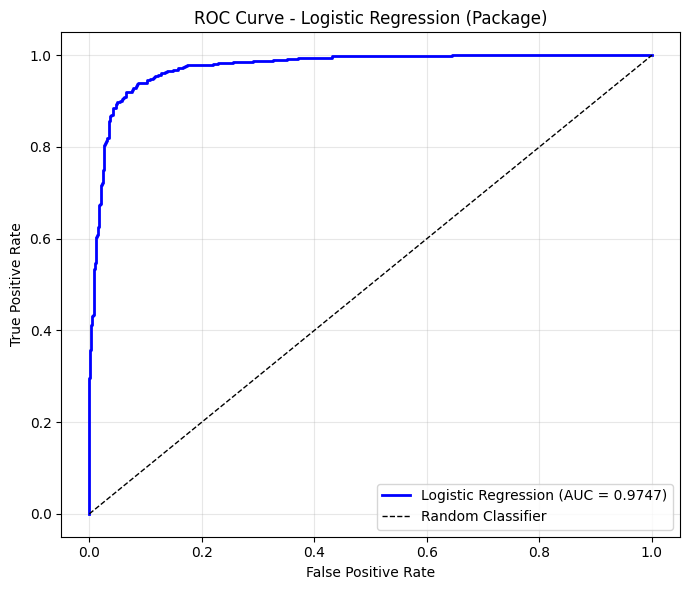

AUC = 0.9747


In [17]:
# Problem 3, Part 3: ROC curve (package) for logistic regression
y_test_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

fpr_pkg, tpr_pkg, thresholds_pkg = roc_curve(y_test, y_test_proba_lr)
auc_pkg = auc(fpr_pkg, tpr_pkg)

plt.figure(figsize=(7, 6))
plt.plot(fpr_pkg, tpr_pkg, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {auc_pkg:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (Package)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_package.png', dpi=150)
plt.show()

print(f"AUC = {auc_pkg:.4f}")

### Part 4: ROC curve (manual)

Threshold         FPR      TPR
------------------------------
0              1.0000   1.0000
0.1            0.3077   0.9874
0.2            0.1524   0.9684
0.3            0.0917   0.9389
0.4            0.0636   0.9095
0.5            0.0385   0.8674
0.6            0.0340   0.8295
0.7            0.0266   0.7874
0.8            0.0222   0.7179
0.9            0.0118   0.6000
1.0            0.0000   0.0021


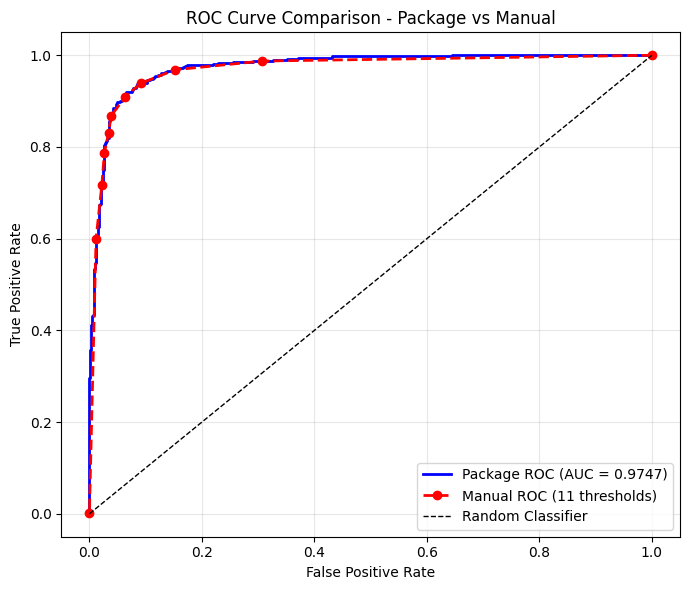

In [18]:
# Problem 3, Part 4: ROC curve (manual) for logistic regression
manual_thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

fpr_manual = []
tpr_manual = []

print(f"{'Threshold':<12} {'FPR':>8} {'TPR':>8}")
print("-" * 30)

for T in manual_thresholds:
    y_pred_t = (y_test_proba_lr >= T).astype(int)
    
    # True positives, false positives, true negatives, false negatives
    tp = np.sum((y_pred_t == 1) & (y_test == 1))
    fp = np.sum((y_pred_t == 1) & (y_test == 0))
    tn = np.sum((y_pred_t == 0) & (y_test == 0))
    fn = np.sum((y_pred_t == 0) & (y_test == 1))
    
    fpr_t = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr_t = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    fpr_manual.append(fpr_t)
    tpr_manual.append(tpr_t)
    
    print(f"{T:<12} {fpr_t:>8.4f} {tpr_t:>8.4f}")

# Plot both ROC curves for comparison
plt.figure(figsize=(7, 6))
plt.plot(fpr_pkg, tpr_pkg, 'b-', linewidth=2, label=f'Package ROC (AUC = {auc_pkg:.4f})')
plt.plot(fpr_manual, tpr_manual, 'ro--', linewidth=2, markersize=6, label='Manual ROC (11 thresholds)')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Package vs Manual')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()

### Observations

On LaTeX

---
## Problem 4: Cross Validation

### Part 1: k-Fold CV implementation

In [22]:
def k_fold_cv(X, y, model_class, k, **model_kwargs):
    """
    k-fold cross-validation implementation from scratch.
    
    Parameters:
        X: feature matrix (N x d)
        y: target vector (N,)
        model_class: sklearn classifier class (e.g., LogisticRegression)
        k: number of folds
        **model_kwargs: keyword arguments passed to the model constructor
    
    Returns:
        avg_error: average validation error across k folds
        fold_errors: list of validation errors for each fold
    """
    N = X.shape[0]
    indices = np.arange(N)
    np.random.shuffle(indices)
    
    # Divide into k partitions of equal size
    fold_size = N // k
    fold_errors = []
    
    for i in range(k):
        # Partition i is the validation set
        val_start = i * fold_size
        val_end = val_start + fold_size if i < k - 1 else N
        
        val_idx = indices[val_start:val_end]
        train_idx = np.concatenate([indices[:val_start], indices[val_end:]])
        
        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]
        
        # Standardize within fold (fit on train, transform both)
        fold_scaler = StandardScaler()
        X_train_fold = fold_scaler.fit_transform(X_train_fold)
        X_val_fold = fold_scaler.transform(X_val_fold)
        
        # Train and predict
        model = model_class(**model_kwargs)
        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)
        
        # Validation error = 1 - accuracy
        val_error = 1 - accuracy_score(y_val_fold, y_val_pred)
        fold_errors.append(val_error)
    
    avg_error = np.mean(fold_errors)
    return avg_error, fold_errors

### Part 2: CV for LR and LDA with k=5,10

In [25]:
# Problem 4, Part 2: Run CV for LR and LDA with k=5,10
# Use the full dataset (X, y) for cross-validation
np.random.seed(42)

models = {
    'Logistic Regression': (LogisticRegression, {'max_iter': 10000, 'random_state': 42}),
    'LDA': (LinearDiscriminantAnalysis, {})
}

k_values = [5, 10]

results = []
for name, (model_class, kwargs) in models.items():
    for k in k_values:
        avg_err, fold_errs = k_fold_cv(X, y, model_class, k, **kwargs)
        results.append({'Model': name, 'k': k, 'Avg Val Error': avg_err})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  k  Avg Val Error
Logistic Regression  5       0.075854
Logistic Regression 10       0.074986
                LDA  5       0.111932
                LDA 10       0.112797


### Part 3: Comparison

On LaTeX